# Actividad 2 - EDA básico
### Data set elegido: 1980s Classic Hits with Spotify Data

In [2]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe

In [5]:
#Dataset
df=pd.read_csv("../datasets/1980sClassics.csv")

### Exploración inicial

In [8]:
print(f"Dimensiones del dataset original: {df.shape}")
df.head()

Dimensiones del dataset original: (998, 17)


,Track,Artist,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity,Year
0,Babe,Styx,3:38,4,0.700,0.582,11,-5.960,0,0.0356,0.05020,0.000000,0.0881,0.785,116.712,96,1980
1,The Rose,Bette Midler,4:04,4,0.264,0.640,8,-6.221,1,0.0442,0.03930,0.000002,0.1510,0.190,84.828,92,1980
2,Cars,Gary Numan,4:08,4,0.338,0.562,9,-7.181,1,0.0290,0.03900,0.000000,0.1070,0.259,149.907,82,1980
3,Magic,Olivia Newton-John,2:17,4,0.911,0.689,1,-6.176,1,0.2650,0.00119,0.000000,0.0704,0.546,140.034,80,1980
4,We Don’t Talk Anymore,Cliff Richard,3:37,4,0.728,0.563,1,-8.053,0,0.1340,0.62100,0.000000,0.1790,0.352,100.017,80,1980


In [9]:
df.columns


Index(['Track', 'Artist', 'Duration', 'Time_Signature', 'Danceability',
       'Energy', 'Key', 'Loudness', 'Mode', 'Speechiness', 'Acousticness',
       'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Popularity',
       'Year'],
      dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Track             998 non-null    object 
 1   Artist            998 non-null    object 
 2   Duration          998 non-null    object 
 3   Time_Signature    998 non-null    int64  
 4   Danceability      998 non-null    float64
 5   Energy            998 non-null    float64
 6   Key               998 non-null    int64  
 7   Loudness          998 non-null    float64
 8   Mode              998 non-null    int64  
 9   Speechiness       998 non-null    float64
 10  Acousticness      998 non-null    float64
 11  Instrumentalness  998 non-null    float64
 12  Liveness          998 non-null    float64
 13  Valence           998 non-null    float64
 14  Tempo             998 non-null    float64
 15  Popularity        998 non-null    int64  
 16  Year              998 non-null    int64  
dt

In [16]:
df.isna().sum()
#Logico que no haya nulos como muestra info

Track               0
Artist              0
Duration            0
Time_Signature      0
Danceability        0
Energy              0
Key                 0
Loudness            0
Mode                0
Speechiness         0
Acousticness        0
Instrumentalness    0
Liveness            0
Valence             0
Tempo               0
Popularity          0
Year                0
dtype: int64

**Conclusiones de exploracion inicial**

El dataset contiene 998 filas y 17 columnas. No se hay valores faltantes según `df.info()`, ya que todas las columnas tienen 998 valores no nulos. Las variables incluyen columnas categóricas y numéricas. Tengo que prestar atencion a que duracion aparece como object, probablemente porque pandas lo interpreta como texto, pero es un numero de lo qeu dura la cacncion "3:45" por ej.


### EDA
Al ver los tipos de variables, veo el problema de la duracion, asi que sigo el notebok de la clase para identificar y cambiar tipos de variables

In [17]:
# Pandas no necesariamente asigna el dtype en forma correcta al importar.
# Conviene revisar cada variable y asignar el tipo de dato correcto.

# Primero convertimos Duration, que vino como texto, a una variable numérica.
df["Duration_seconds"] = pd.to_timedelta("00:" + df["Duration"]).dt.total_seconds()
df["Duration_minutes"] = df["Duration_seconds"] / 60

spotify_numericas = [
    "Duration_seconds",
    "Duration_minutes",
    "Danceability",
    "Energy",
    "Loudness",
    "Speechiness",
    "Acousticness",
    "Instrumentalness",
    "Liveness",
    "Valence",
    "Tempo",
    "Popularity",
    "Year"
]

spotify_cat_nom = [
    "Track",
    "Artist",
    "Key",
    "Mode",
    "Time_Signature"
]

dtype_map = {col: "float64" for col in spotify_numericas if col in df.columns}
dtype_map.update({col: "category" for col in spotify_cat_nom if col in df.columns})

df = df.astype(dtype_map)

df.dtypes


Track               category
Artist              category
Duration              object
Time_Signature      category
Danceability         float64
Energy               float64
Key                 category
Loudness             float64
Mode                category
Speechiness          float64
Acousticness         float64
Instrumentalness     float64
Liveness             float64
Valence              float64
Tempo                float64
Popularity           float64
Year                 float64
Duration_seconds     float64
Duration_minutes     float64
dtype: object

Importante, aunque key, mode y time_signature son numeros, representa do, re mi, mode es mayor o menor (0 y 1) y time_signature es el compas, tipo 4/4 entonces conceptualmente son categoricas.

In [18]:
df["Key"].value_counts().sort_index()


Key
0     138
1      93
2      96
3      28
4      80
5      85
6      56
7     102
8      53
9     125
10     60
11     82
Name: count, dtype: int64

In [19]:
df["Time_Signature"].value_counts().sort_index()


Time_Signature
1      2
3     31
4    961
5      4
Name: count, dtype: int64

### Estadística descriptiva

In [24]:
num_cols = df.select_dtypes(include="number").columns
cat_cols = df.select_dtypes(include="category").columns

print("Variables numéricas:")
print(list(num_cols))

print("Variables categóricas:")
print(list(cat_cols))


Variables numéricas:
['Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Popularity', 'Year', 'Duration_seconds', 'Duration_minutes']
Variables categóricas:
['Track', 'Artist', 'Time_Signature', 'Key', 'Mode']


In [21]:
df.describe(include="number")

,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity,Year,Duration_seconds,Duration_minutes
count,998.000000,998.000000,998.000000,998.00000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000
mean,0.626469,0.633362,-8.886123,0.05763,0.244627,0.042554,0.178618,0.603099,120.904174,57.743487,1984.498998,240.101202,4.001687
std,0.151517,0.203787,3.829896,0.05574,0.248634,0.157057,0.162648,0.257874,26.254971,17.397193,2.873372,63.779261,1.062988
min,0.174000,0.018300,-28.980000,0.02270,0.000003,0.000000,0.022300,0.028700,61.530000,0.000000,1980.000000,41.000000,0.683333
25%,0.534000,0.489000,-11.256000,0.03170,0.043350,0.000000,0.083950,0.388000,102.303000,49.000000,1982.000000,205.000000,3.416667
50%,0.633000,0.651500,-8.270000,0.03935,0.155000,0.000022,0.113500,0.644000,119.969000,60.000000,1984.500000,234.000000,3.900000
75%,0.735000,0.797000,-6.045000,0.05645,0.387250,0.001448,0.225750,0.824750,135.000750,70.000000,1987.000000,270.000000,4.500000
max,0.988000,0.994000,-1.496000,0.52400,0.996000,0.974000,0.981000,0.984000,208.571000,96.000000,1989.000000,929.000000,15.483333


Las canciones tienen promedios medios/altos de bailabilidad, energía y valencia (una medida de Spotify que representa que tan positiva o alegre suena una cancion, va de 0 a 1), lo que sugiere que muchas canciones del dataset son bailables y con tono positivo.
La duración promedio es de aproximadamente 4 minutos, aunque se observa un valor máximo de más de 15 minutos, puede ser un outlier, una grabacion de instrumental (o tal vez se la olvidaron prendida jaja).
La popularidad promedio ronda los 58 puntos, con una gran dispersión entre canciones poco populares y canciones muy populares.


In [23]:
df.describe(include="category")

,Track,Artist,Time_Signature,Key,Mode
count,998,998,998,998,998
unique,972,475,4,12,2
top,Always On My Mind,Madonna,4,0,1
freq,2,17,961,138,688


El dataset contiene 998 canciones, con 972 únicos (canciones repetidas o distintas versiones de un mismo tema).
El artista más frecuente es Madonna (para sorpresa de nadie), con 17 canciones. 
La mayoría de las canciones tiene compás 4/4 y modo 1,ritmo muy típico de pop/rock tono mayor, que entiendo que se relaciona con música más alegre.


In [25]:
df[["Track", "Artist", "Popularity"]].sort_values("Popularity", ascending=False).head(10)


,Track,Artist,Popularity
0,Babe,Styx,96.0
399,Cruel Summer,Bananarama,93.0
1,The Rose,Bette Midler,92.0
100,Together,Tierra,92.0
200,Do I Do,Stevie Wonder,91.0
699,Control,Janet Jackson,91.0
898,Stand,R.E.M.,90.0
299,My Love,Lionel Richie,89.0
499,Take On Me,a-ha,88.0
799,Red Red Wine,UB40,88.0


Aunque Madonna es la artista que mas aparece, no es la de mayor popularidad, ni siquiera esta en el top ten (esto me sorprendió)

## Gráfico 1: Popularidad



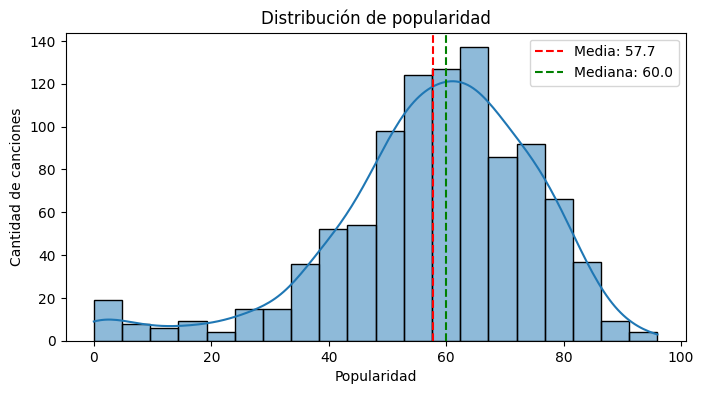

In [26]:
plt.figure(figsize=(8, 4))

sns.histplot(data=df, x="Popularity", bins=20, kde=True)

plt.axvline(df["Popularity"].mean(), color="red", linestyle="--", label=f"Media: {df['Popularity'].mean():.1f}")
plt.axvline(df["Popularity"].median(), color="green", linestyle="--", label=f"Mediana: {df['Popularity'].median():.1f}")

plt.title("Distribución de popularidad")
plt.xlabel("Popularidad")
plt.ylabel("Cantidad de canciones")
plt.legend()
plt.show()


## Gráfico 2: Duración

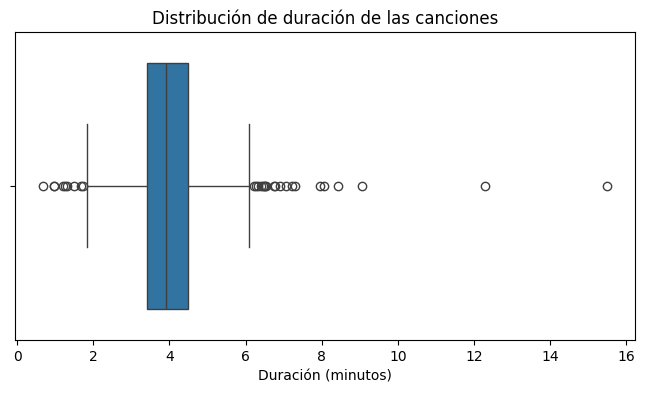

In [27]:
plt.figure(figsize=(8, 4))

sns.boxplot(data=df, x="Duration_minutes")

plt.title("Distribución de duración de las canciones")
plt.xlabel("Duración (minutos)")
plt.show()


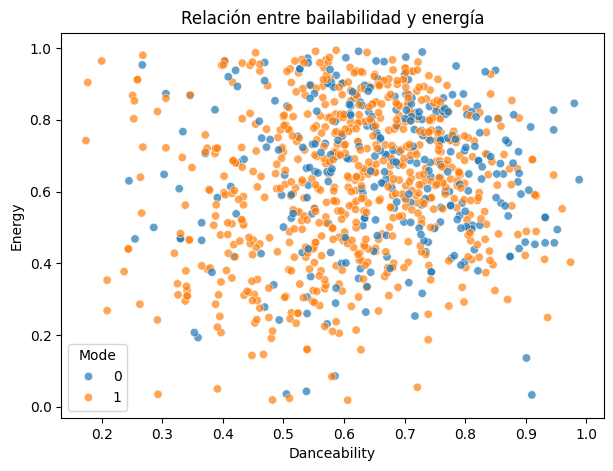

In [28]:
plt.figure(figsize=(7, 5))

sns.scatterplot(data=df, x="Danceability", y="Energy", hue="Mode", alpha=0.7)

plt.title("Relación entre bailabilidad y energía")
plt.xlabel("Danceability")
plt.ylabel("Energy")
plt.show()


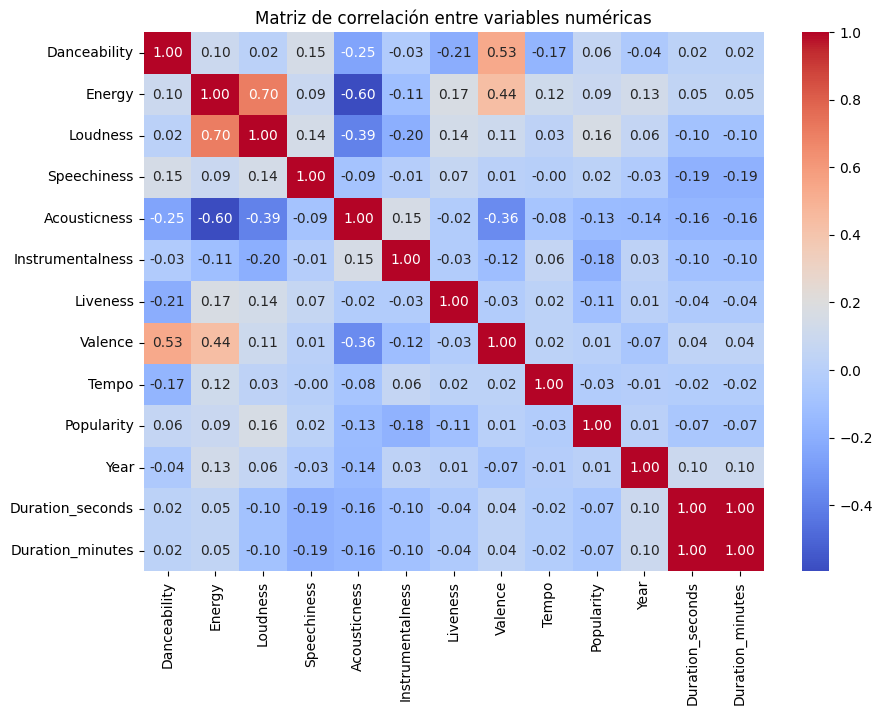

In [29]:
plt.figure(figsize=(10, 7))

corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Matriz de correlación entre variables numéricas")
plt.show()


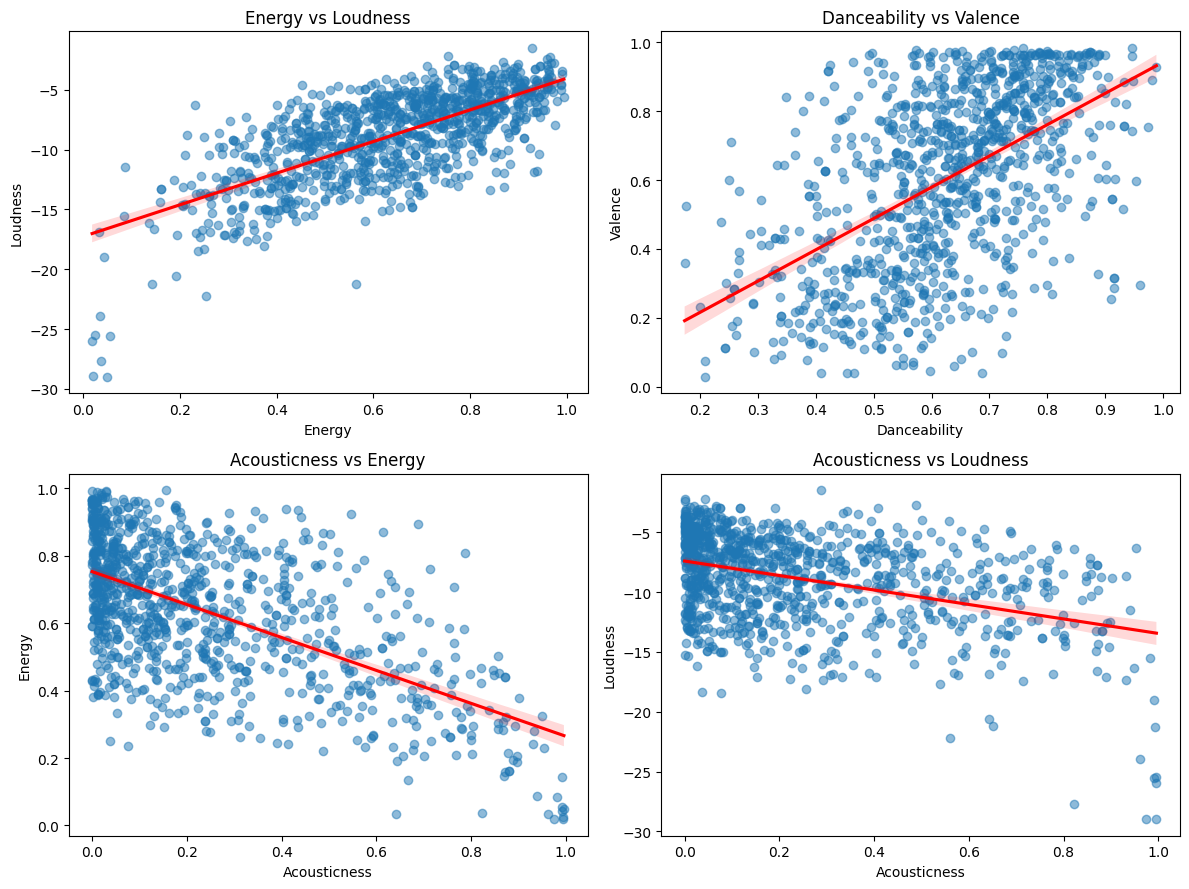

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.regplot(data=df, x="Energy", y="Loudness", ax=axes[0, 0], scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
axes[0, 0].set_title("Energy vs Loudness")

sns.regplot(data=df, x="Danceability", y="Valence", ax=axes[0, 1], scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
axes[0, 1].set_title("Danceability vs Valence")

sns.regplot(data=df, x="Acousticness", y="Energy", ax=axes[1, 0], scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
axes[1, 0].set_title("Acousticness vs Energy")

sns.regplot(data=df, x="Acousticness", y="Loudness", ax=axes[1, 1], scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
axes[1, 1].set_title("Acousticness vs Loudness")

plt.tight_layout()
plt.show()


## Graficos de variables categóricas

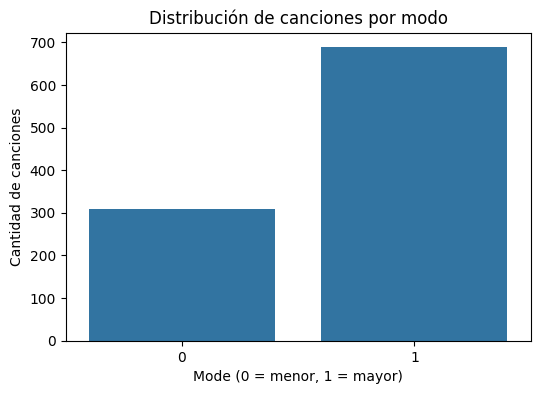

In [ ]:


plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Mode")
plt.title("Distribución de canciones por modo")
plt.xlabel("Mode (0 = menor, 1 = mayor)")
plt.ylabel("Cantidad de canciones")
plt.show()


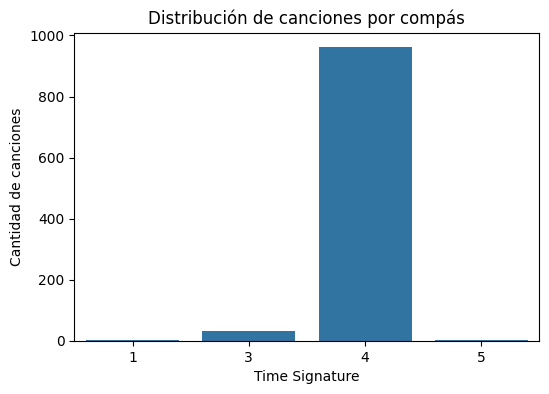

In [33]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Time_Signature")
plt.title("Distribución de canciones por compás")
plt.xlabel("Time Signature")
plt.ylabel("Cantidad de canciones")
plt.show()


### Tomo sugerencias de Claude

In [38]:
resumen_numericas = pd.DataFrame({
    "media": df[spotify_numericas].mean(),
    "mediana": df[spotify_numericas].median(),
    "desvio_std": df[spotify_numericas].std(),
    "Q1": df[spotify_numericas].quantile(0.25),
    "Q3": df[spotify_numericas].quantile(0.75),
    "IQR": df[spotify_numericas].quantile(0.75) - df[spotify_numericas].quantile(0.25),
    "skewness": df[spotify_numericas].skew(),
    "curtosis": df[spotify_numericas].kurt()
})

resumen_numericas


,media,mediana,desvio_std,Q1,Q3,IQR,skewness,curtosis
Duration_seconds,240.101202,234.000000,63.779261,205.000000,270.000000,65.000000,2.092046,17.797829
Duration_minutes,4.001687,3.900000,1.062988,3.416667,4.500000,1.083333,2.092046,17.797829
Danceability,0.626469,0.633000,0.151517,0.534000,0.735000,0.201000,-0.312281,-0.164159
Energy,0.633362,0.651500,0.203787,0.489000,0.797000,0.308000,-0.440285,-0.337540
Loudness,-8.886123,-8.270000,3.829896,-11.256000,-6.045000,5.211000,-1.106998,2.510072
Speechiness,0.057630,0.039350,0.055740,0.031700,0.056450,0.024750,3.943758,18.809282
Acousticness,0.244627,0.155000,0.248634,0.043350,0.387250,0.343900,1.143186,0.396593
Instrumentalness,0.042554,0.000022,0.157057,0.000000,0.001448,0.001448,4.458716,19.700856
Liveness,0.178618,0.113500,0.162648,0.083950,0.225750,0.141800,2.451755,7.022034
Valence,0.603099,0.644000,0.257874,0.388000,0.824750,0.436750,-0.334124,-1.046373


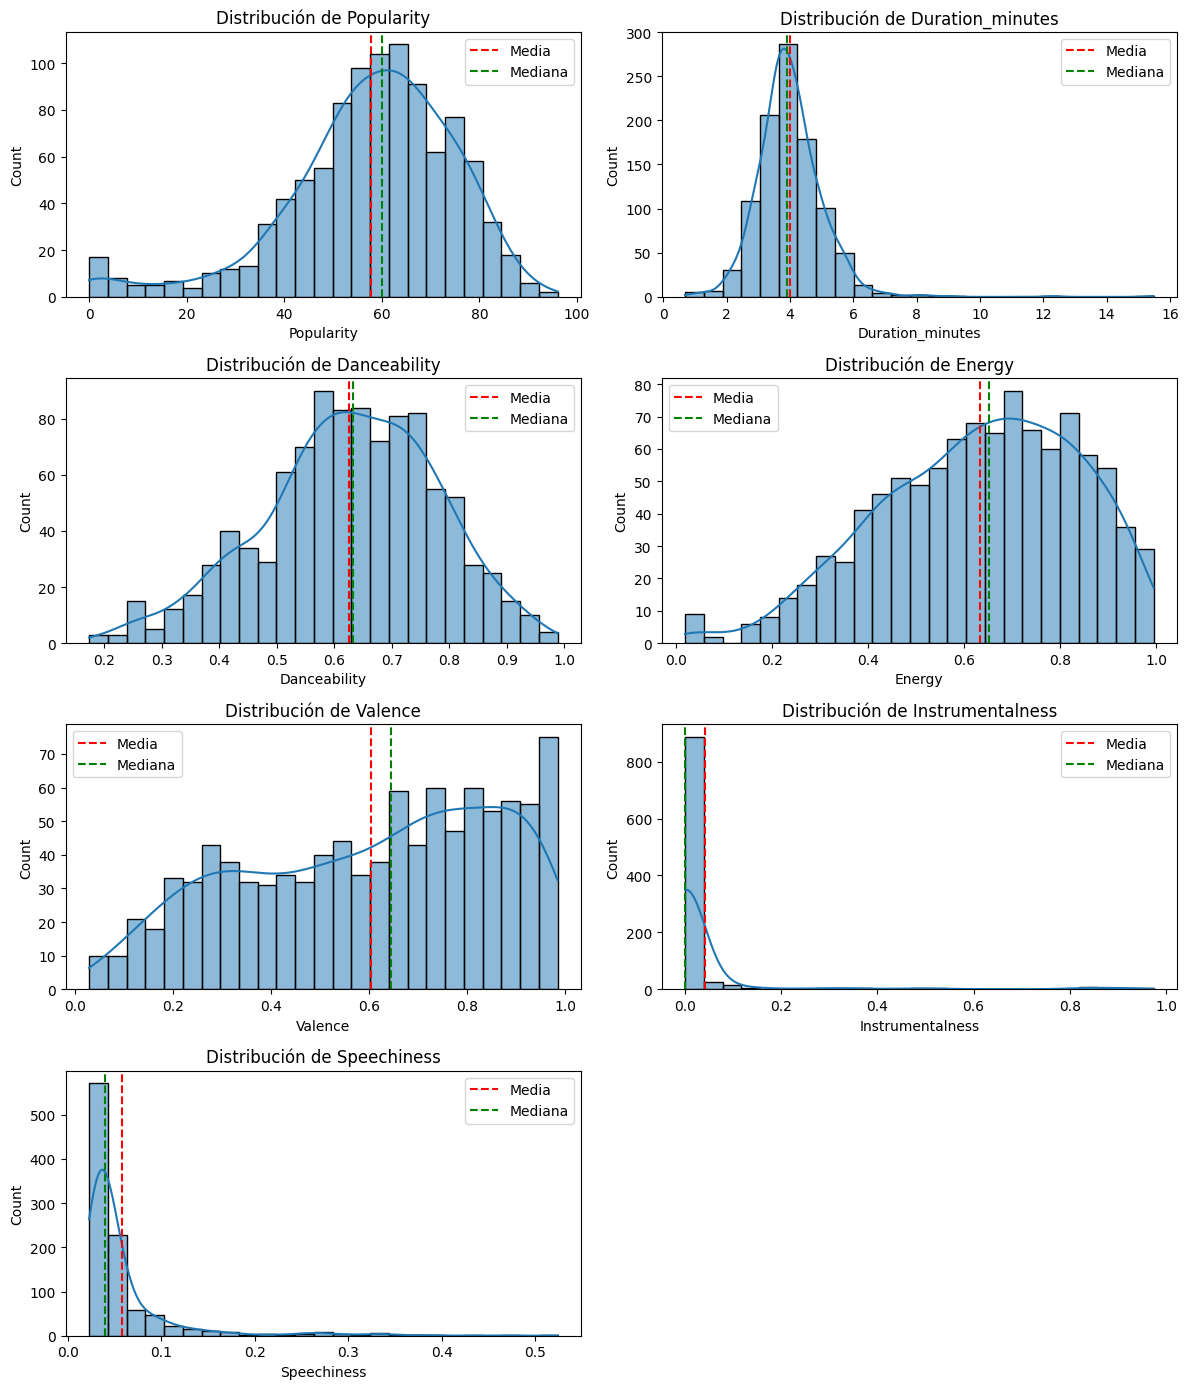

In [39]:
variables_a_graficar = [
    "Popularity",
    "Duration_minutes",
    "Danceability",
    "Energy",
    "Valence",
    "Instrumentalness",
    "Speechiness"
]

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()

for i, col in enumerate(variables_a_graficar):
    sns.histplot(data=df, x=col, kde=True, bins=25, ax=axes[i])
    axes[i].axvline(df[col].mean(), color="red", linestyle="--", label="Media")
    axes[i].axvline(df[col].median(), color="green", linestyle="--", label="Mediana")
    axes[i].set_title(f"Distribución de {col}")
    axes[i].legend()

axes[-1].axis("off")
plt.tight_layout()
plt.show()


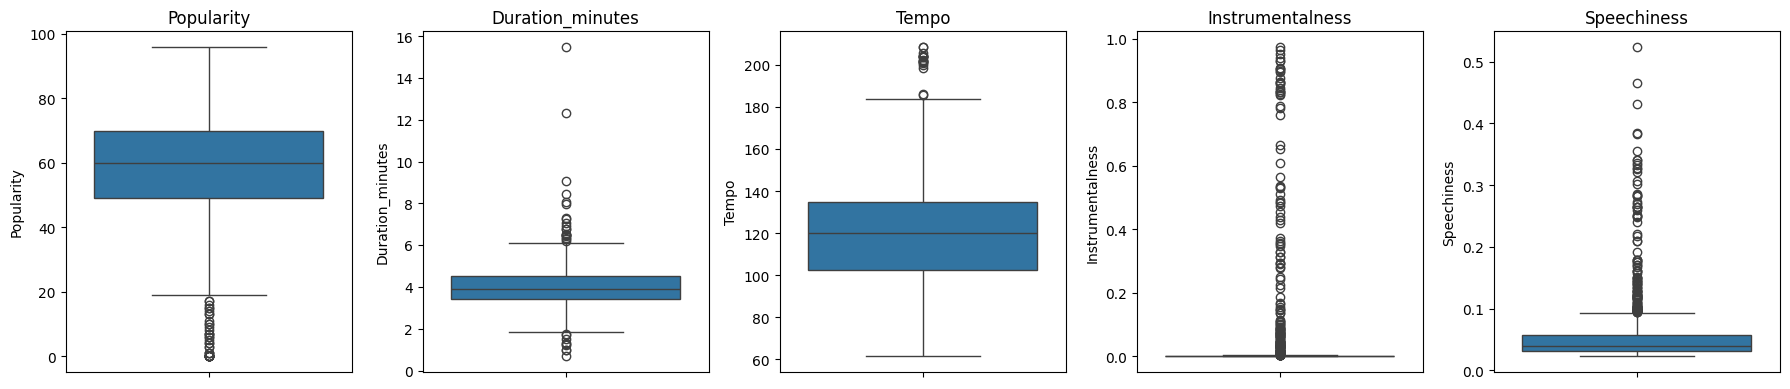

In [45]:
variables_boxplot = [
    "Popularity",
    "Duration_minutes",
    "Tempo",
    "Instrumentalness",
    "Speechiness"
]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, col in enumerate(variables_boxplot):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


In [46]:
for col in ["Mode", "Time_Signature", "Key"]:
    print(f"\nVariable: {col}")
    print(df[col].value_counts().sort_index())



Variable: Mode
Mode
0    310
1    688
Name: count, dtype: int64

Variable: Time_Signature
Time_Signature
1      2
3     31
4    961
5      4
Name: count, dtype: int64

Variable: Key
Key
0     138
1      93
2      96
3      28
4      80
5      85
6      56
7     102
8      53
9     125
10     60
11     82
Name: count, dtype: int64


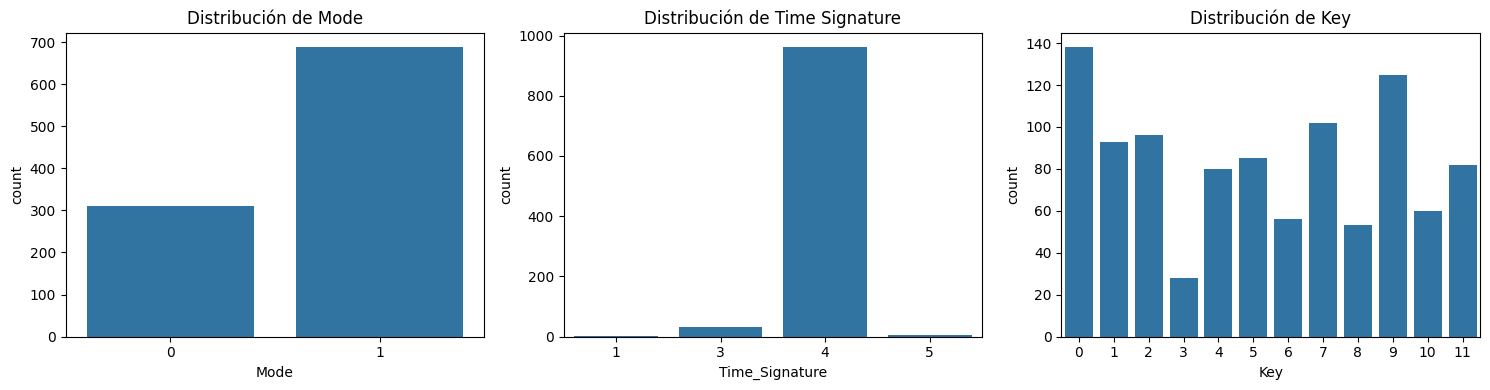

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df, x="Mode", ax=axes[0])
axes[0].set_title("Distribución de Mode")

sns.countplot(data=df, x="Time_Signature", ax=axes[1])
axes[1].set_title("Distribución de Time Signature")

sns.countplot(data=df, x="Key", ax=axes[2])
axes[2].set_title("Distribución de Key")

plt.tight_layout()
plt.show()


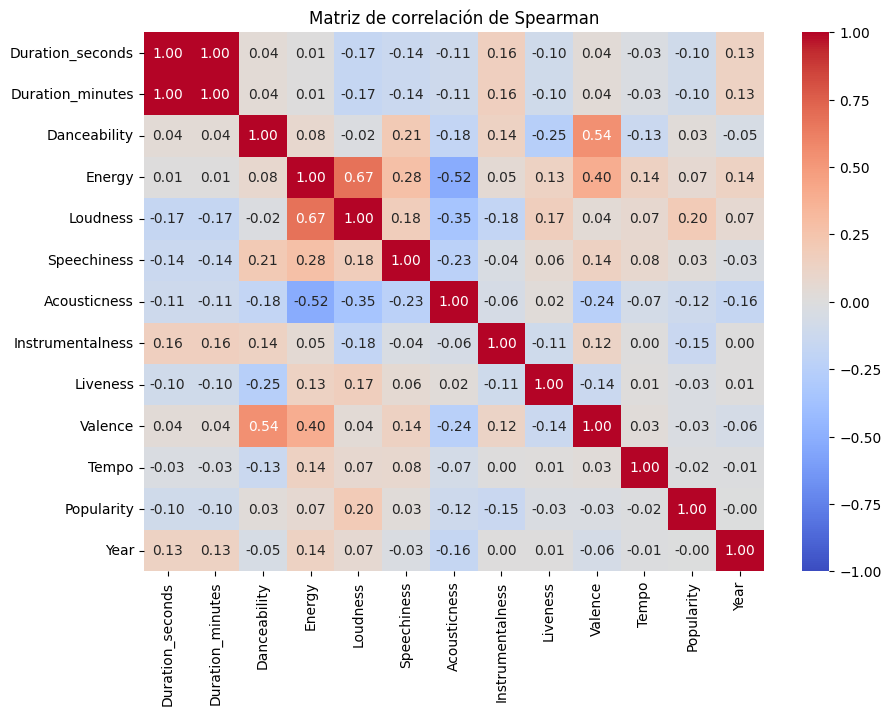

In [49]:
plt.figure(figsize=(10, 7))

corr_spearman = df[spotify_numericas].corr(method="spearman")

sns.heatmap(corr_spearman, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de correlación de Spearman")
plt.show()


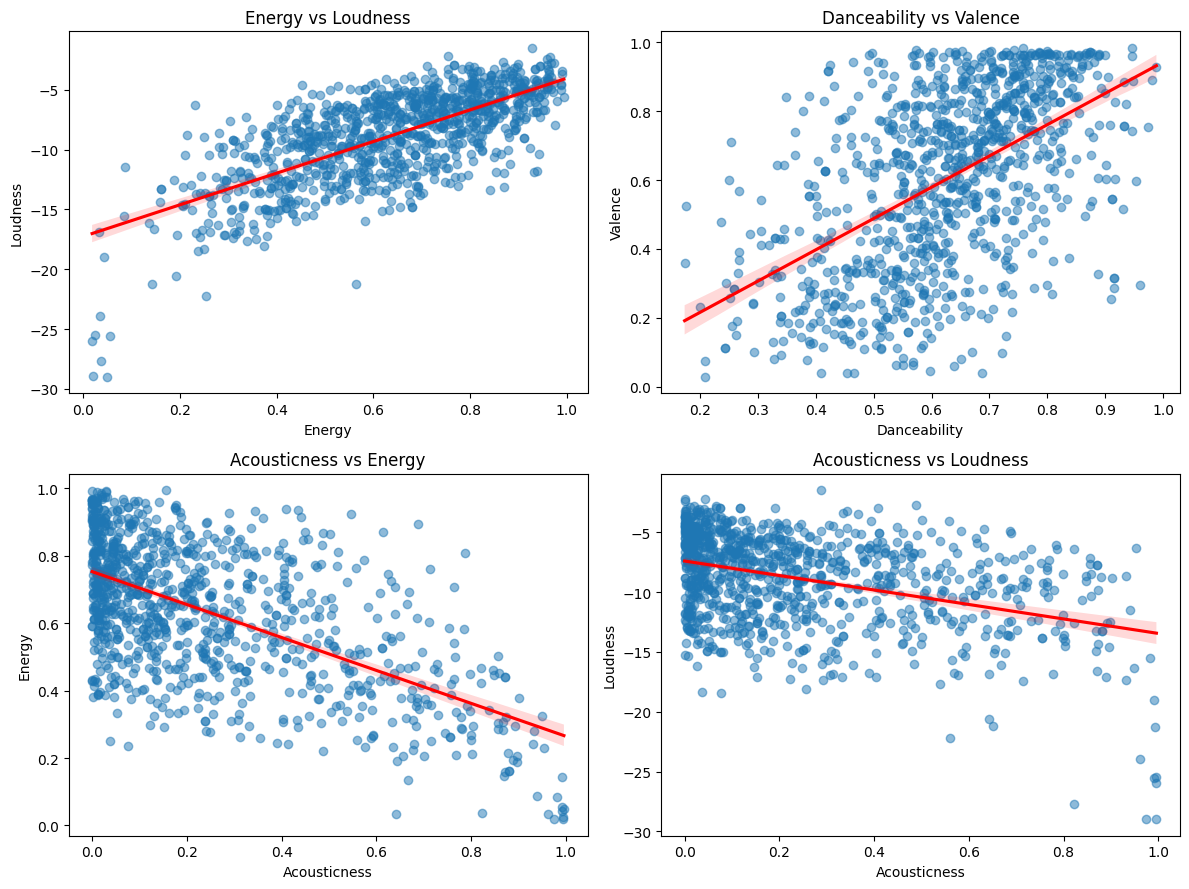

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.regplot(data=df, x="Energy", y="Loudness", ax=axes[0, 0], scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
axes[0, 0].set_title("Energy vs Loudness")

sns.regplot(data=df, x="Danceability", y="Valence", ax=axes[0, 1], scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
axes[0, 1].set_title("Danceability vs Valence")

sns.regplot(data=df, x="Acousticness", y="Energy", ax=axes[1, 0], scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
axes[1, 0].set_title("Acousticness vs Energy")

sns.regplot(data=df, x="Acousticness", y="Loudness", ax=axes[1, 1], scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
axes[1, 1].set_title("Acousticness vs Loudness")

plt.tight_layout()
plt.show()


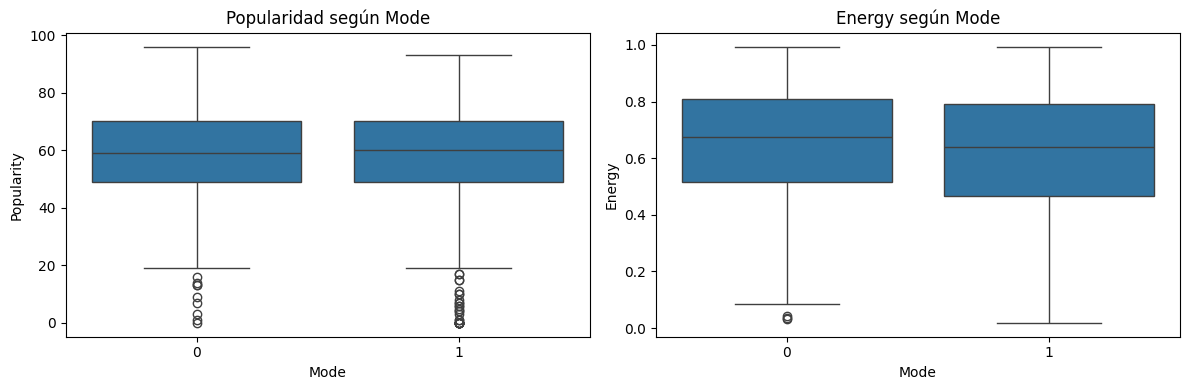

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x="Mode", y="Popularity", ax=axes[0])
axes[0].set_title("Popularidad según Mode")

sns.boxplot(data=df, x="Mode", y="Energy", ax=axes[1])
axes[1].set_title("Energy según Mode")

plt.tight_layout()
plt.show()


In [52]:
df.groupby("Mode", observed=True)[["Popularity", "Energy", "Valence"]].describe()


Popularity                                                    Energy  \
          count       mean        std  min   25%   50%   75%   max  count   
Mode                                                                        
0         310.0  58.116129  16.553123  0.0  49.0  59.0  70.0  96.0  310.0   
1         688.0  57.575581  17.773607  0.0  49.0  60.0  70.0  93.0  688.0   

                ...                 Valence                              \
          mean  ...      75%    max   count      mean       std     min   
Mode            ...                                                       
0     0.652361  ...  0.80900  0.991   310.0  0.642381  0.254046  0.0395   
1     0.624802  ...  0.79175  0.994   688.0  0.585399  0.257813  0.0287   

                                       
          25%     50%      75%    max  
Mode                                   
0     0.43775  0.6910  0.86575  0.984  
1     0.36150  0.6245  0.80450  0.978  

[2 rows x 24 columns]